In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

df = pd.read_csv('../data/processed/iris_cleaned.csv')
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
dt  = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
svm = SVC(kernel='rbf', random_state=42).fit(X_train, y_train)
print("All 3 models trained!")

All 3 models trained!


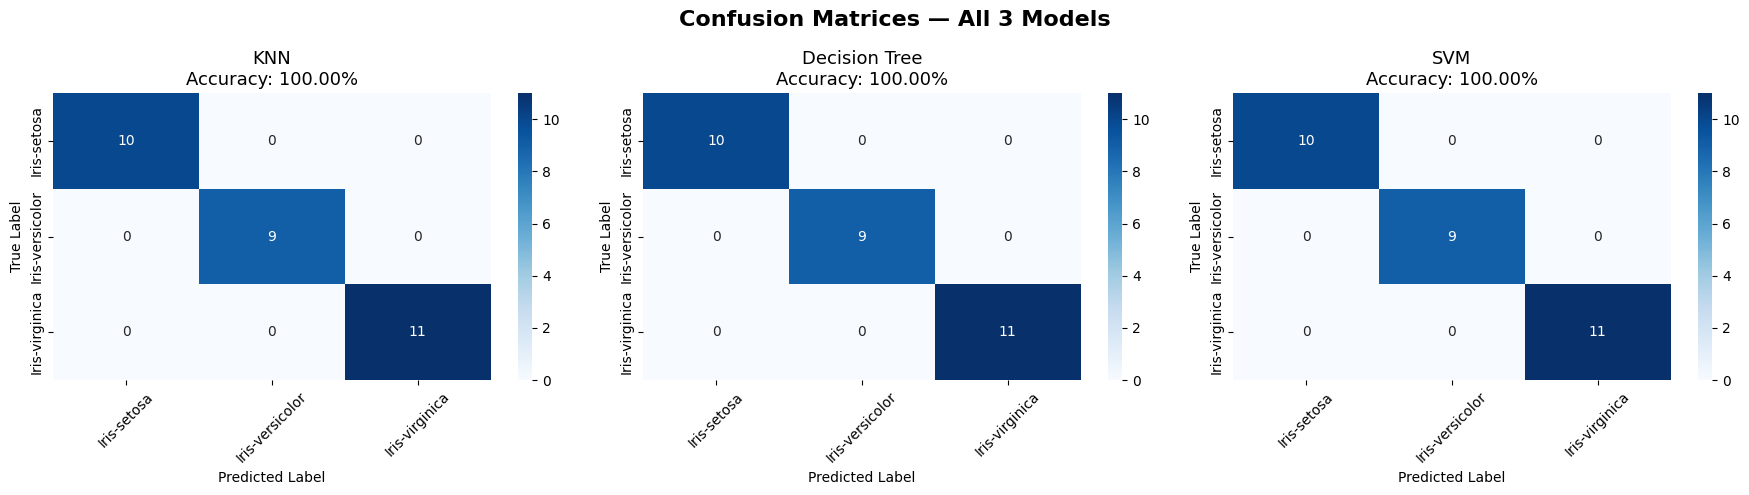

Saved!


In [3]:
models = {
    'KNN':           (knn, knn.predict(X_test)),
    'Decision Tree': (dt,  dt.predict(X_test)),
    'SVM':           (svm, svm.predict(X_test)),
}
classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All 3 Models', fontsize=16, fontweight='bold')

for ax, (name, (model, y_pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}', fontsize=13)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved!")

In [4]:
for name, (model, y_pred) in models.items():
    print(f"\n{'='*40}")
    print(f"{name} Classification Report")
    print('='*40)
    print(classification_report(y_test, y_pred, target_names=classes))


KNN Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Decision Tree Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


SVM Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00 